# Plant Disease Assistant: Experiments and Results

This notebook presents the complete experimental workflow: **datasets → model training →
five-fold cross-validation → holdout and cross-domain evaluation → efficiency → robustness →
explanations**. It compares a disease-aware YOLO11n model with three two-stage systems that use
lesion localization followed by disease classification.


## 1. Setup

This section imports the required libraries, resolves the project paths, loads the trained models,
and defines the locations of the experimental results used throughout the notebook.


In [1]:
from pathlib import Path
import hashlib
import json
import shutil
import sys
import zipfile

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import Markdown, display


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'configs' / 'project.yaml').is_file():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the project checkout')


def sha256(path):
    with path.open('rb') as handle:
        return hashlib.file_digest(handle, 'sha256').hexdigest()


ROOT = find_project_root()
OUTPUTS = ROOT / 'outputs'
config = yaml.safe_load((ROOT / 'configs/project.yaml').read_text())
model_names = ['baseline_cnn', 'efficientnet_b0', 'mobilenet_v3_large']
model_labels = dict(zip(model_names, ['Baseline CNN', 'EfficientNetB0', 'MobileNetV3-Large']))
archive = ROOT / 'plant-disease-checkpoints.zip'
if not archive.is_file():
    raise FileNotFoundError('Place plant-disease-checkpoints.zip in the project root.')
if archive.is_file():
    CHECKPOINTS = OUTPUTS / 'imported_checkpoints' / sha256(archive)[:16] / 'outputs'
    expected = [f'classification/{name}/best.pt' for name in model_names] + [
        f"yolo/{config['detection'][key]}/weights/best.pt"
        for key in ['run_name', 'standalone_run_name']
    ]
    with zipfile.ZipFile(archive) as bundle:
        for relative in expected:
            member = 'outputs/' + relative
            if member not in bundle.namelist():
                raise ValueError(f'Missing checkpoint in archive: {member}')
            destination = CHECKPOINTS / relative
            if not destination.is_file():
                destination.parent.mkdir(parents=True, exist_ok=True)
                temporary = destination.with_suffix('.tmp')
                with bundle.open(member) as source, temporary.open('wb') as target:
                    shutil.copyfileobj(source, target)
                temporary.replace(destination)

EVALUATIONS = CHECKPOINTS.parent / 'evaluations'


pd.options.display.max_colwidth = 80
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

artifacts = {
    'Primary holdout': EVALUATIONS / 'plantseg_test/summary.json',
    'Cross-validation': OUTPUTS / 'cross_validation/cv_summary.json',
    'Cross-domain': EVALUATIONS / 'cross_domain/summary.json',
    'Efficiency': EVALUATIONS / 'efficiency/summary.json',
    'Grad-CAM': EVALUATIONS / 'gradcam/summary.json',
    'Robustness (full)': EVALUATIONS / 'robustness_full/summary.json',
    'Robustness (subset)': EVALUATIONS / 'robustness/summary.json',
}


## 2. Datasets and experimental design

**Purpose.** Establish which images are used for learning, selection, and testing before
looking at any model scores. PlantSeg provides field photographs, lesion masks, and a
115-class disease taxonomy. The official training split fits the models; official validation
supports the main-run checkpoint selection; the official test split remains a holdout.
Masks provide bounding-box supervision and later serve as a reference for Grad-CAM.

Five-fold CV uses **only the official training pool**, with disease-stratified folds and
round-robin allocation for classes with fewer than five examples. The current implementation
is not source-URL grouped. Official validation and test images stay outside CV.

The cross-domain experiment restricts PlantSeg and PlantVillage to the same 21 mapped disease
labels. PlantVillage is a controlled-image domain, so this measures transfer across acquisition
conditions. PlantDoc is optional backup data, not part of these required experiments.
The following inventory separates available metadata by split and reports missing views explicitly.


In [2]:
metadata_files = {
    'PlantSeg development': ROOT / 'data/training/PlantSeg/Metadata.csv',
    'PlantSeg full test': ROOT / 'data/tests/PlantSeg/full/Metadata.csv',
    'PlantSeg mapped test': ROOT / 'data/tests/overlap/PlantSeg/Metadata.csv',
    'PlantVillage mapped test': ROOT / 'data/tests/overlap/PlantVillage/Metadata.csv',
}
coverage = []
for name, path in metadata_files.items():
    if not path.is_file():
        coverage.append({'Dataset view': name, 'Split': 'Unavailable', 'Images': None, 'Classes': None})
        continue
    frame = pd.read_csv(path)
    groups = frame.groupby('Split') if 'Split' in frame else [('Test', frame)]
    for split, group in groups:
        coverage.append({'Dataset view': name, 'Split': split,
                         'Images': len(group), 'Classes': group['Index'].nunique()})
display(pd.DataFrame(coverage).style.format({'Images': '{:.0f}', 'Classes': '{:.0f}'},
                                           na_rep='N/A').hide(axis='index'))


Dataset view,Split,Images,Classes
PlantSeg development,Training,5367,115
PlantSeg full test,Test,1561,114
PlantSeg mapped test,Test,378,21
PlantVillage mapped test,Test,6057,21


## 3. Detector training and crop preparation

**Purpose.** Compare a single-stage disease detector with a two-stage system that separates
lesion localization from disease recognition. Both approaches use YOLO11n. The class-agnostic
detector learns a single lesion class, while the standalone detector learns all disease classes
directly. Bounding boxes are derived from the PlantSeg lesion masks.

For the two-stage systems, the union of the detected lesion boxes is expanded by a small margin
and passed to the classifier. If no lesion is detected, the classifier receives the full image.
For standalone YOLO, a missed detection counts as an incorrect disease prediction.


In [3]:
detector_rows = []
for label, key in [('Lesion YOLO11n', 'run_name'), ('Disease-aware YOLO11n', 'standalone_run_name')]:
    path = CHECKPOINTS / 'yolo' / config['detection'][key] / 'weights/best.pt'
    detector_rows.append({'Detector': label, 'Weights available': path.is_file(),
                          'Checkpoint': str(path.relative_to(ROOT))})
display(pd.DataFrame(detector_rows).style.hide(axis='index'))


Detector,Weights available,Checkpoint
Lesion YOLO11n,True,outputs/imported_checkpoints/d642c4c7a00b6832/outputs/yolo/plantseg_lesion_10ep/weights/best.pt
Disease-aware YOLO11n,True,outputs/imported_checkpoints/d642c4c7a00b6832/outputs/yolo/plantseg_disease_10ep/weights/best.pt


## 4. Classifier models and selection criterion

**Purpose.** Compare a small baseline CNN with EfficientNetB0 and MobileNetV3-Large on localized
lesion crops. The baseline provides a simple model trained from scratch, while EfficientNetB0 and
MobileNetV3-Large use transfer learning from ImageNet. MobileNetV3-Large is included specifically
as a mobile-oriented architecture.

Macro F1 on validation data is used for model selection because it gives equal weight to every
represented disease class and is therefore more informative than accuracy for an imbalanced
dataset. Training images use augmentation, while validation and test images use deterministic
resizing and ImageNet normalization.


## 5. Five-fold cross-validation on the training pool

**Purpose.** Estimate how sensitive model performance is to the development split before
examining the official test set. In each fold, both YOLO variants and all three classifiers are
trained on four-fifths of the official PlantSeg training pool and validated on the remaining fifth.
The official validation and test partitions remain outside cross-validation.

Classifier performance is summarized using the best validation macro F1 in each fold. Detector
performance is summarized using precision, recall, mAP@50, and mAP@50-95. The table reports the
mean and population standard deviation across the five folds. Very rare diseases may be absent
from individual validation folds, so the values summarize performance over the classes represented
in each fold.


In [4]:
cv_path = OUTPUTS / 'cross_validation/cv_summary.json'
if cv_path.is_file():
    cv = json.loads(cv_path.read_text())
    cv_rows = []
    for model, values in cv.items():
        row = {'Model': model, 'Folds completed': values.get('folds_completed'),
               'Status': 'Complete' if values.get('folds_completed') == 5 else 'Partial'}
        for key, value in values.items():
            if key.endswith('_mean') and key != 'epochs_mean':
                metric = key[:-5]
                std = values.get(f'{metric}_std')
                row[f'{metric} (mean ± SD)'] = f'{value:.3f} ± {std:.3f}' if std is not None else f'{value:.3f}'
        cv_rows.append(row)
    if cv_rows:
        display(pd.DataFrame(cv_rows).fillna('N/A').style.hide(axis='index'))
    else:
        display(Markdown('> No completed fold metrics in the CV summary.'))
else:
    display(Markdown('> Five-fold results are unavailable. Copy the CV artifacts from the training run, '
                     'or run `PYTHONPATH=src .venv/bin/python scripts/run_cross_validation.py` to train them.'))


Model,Folds completed,Status,precision (mean ± SD),recall (mean ± SD),map50 (mean ± SD),map50_95 (mean ± SD),best_val_macro_f1 (mean ± SD)
lesion_yolo,5,Complete,0.822 ± 0.007,0.802 ± 0.007,0.853 ± 0.006,0.570 ± 0.010,N/A
standalone_yolo,5,Complete,0.491 ± 0.016,0.400 ± 0.027,0.409 ± 0.007,0.290 ± 0.008,N/A
baseline_cnn,5,Complete,N/A,N/A,N/A,N/A,0.201 ± 0.008
efficientnet_b0,5,Complete,N/A,N/A,N/A,N/A,0.594 ± 0.020
mobilenet_v3_large,5,Complete,N/A,N/A,N/A,N/A,0.573 ± 0.014


## 6. Primary PlantSeg holdout

**Purpose.** Compare end-to-end disease recognition on the untouched official PlantSeg test split
after model selection. Accuracy measures the proportion of correct images; macro F1 gives equal
weight to every represented disease class; balanced accuracy averages recall across classes.
Coverage is the fraction of images for which a system returns a disease prediction.

Localization is reported separately. mAP@50 uses an intersection-over-union threshold of 0.50,
while mAP@50-95 averages performance across increasingly strict overlap thresholds. Strong
localization does not necessarily imply correct disease classification.


In [5]:
primary_path = artifacts['Primary holdout']
if primary_path.is_file():
    primary = json.loads(primary_path.read_text())
    rows = []
    standalone = primary['standalone_yolo']['classification']
    rows.append({'System': 'standalone_yolo', **{key: standalone.get(key) for key in ['accuracy', 'macro_f1', 'balanced_accuracy', 'coverage']}})
    for model, values in primary['classification'].items():
        rows.append({'System': f'lesion_yolo + {model}', **{key: values.get(key) for key in ['accuracy', 'macro_f1', 'balanced_accuracy']}, 'coverage': 1.0})
    primary_df = pd.DataFrame(rows)
    display(primary_df.style.format({key: '{:.3f}' for key in ['accuracy', 'macro_f1', 'balanced_accuracy', 'coverage']}).hide(axis='index'))
    localization = pd.DataFrame([
        {'Detector': 'class-agnostic lesion YOLO', **primary['localization']},
        {'Detector': 'disease-aware YOLO', **primary['standalone_yolo']['localization']},
    ]).drop(columns=['speed_ms_per_image'])
    display(localization.style.format(precision=3).hide(axis='index'))

else:
    display(Markdown('> Primary evaluation is not available. Run the holdout command in section 12.'))


System,accuracy,macro_f1,balanced_accuracy,coverage
standalone_yolo,0.614,0.533,0.496,0.865
lesion_yolo + baseline_cnn,0.413,0.290,0.300,1.000
lesion_yolo + efficientnet_b0,0.667,0.590,0.587,1.000
lesion_yolo + mobilenet_v3_large,0.668,0.582,0.587,1.000


Detector,precision,recall,map50,map50_95
class-agnostic lesion YOLO,0.853,0.819,0.882,0.615
disease-aware YOLO,0.549,0.499,0.502,0.345


## 7. Accuracy versus end-to-end latency

**Purpose.** Test whether the two-stage design offers a useful accuracy-cost trade-off for an
interactive deployment. Each system is benchmarked independently at batch size 1, so a cascade
runs the lesion detector and exactly one classifier. Timing includes image loading, detection,
crop construction, preprocessing, and inference; one-time model loading is excluded.

The vertical axis uses accuracy from the complete 1,561-image PlantSeg holdout. The horizontal
axis uses median latency over a fixed 200-image sample after 10 warm-up images; the table also
reports p95 latency. Results describe the recorded computer and backend, not phone latency.
Mobile suitability requires a benchmark of exported and preferably quantized models on the target
device. Parameter counts describe architecture size, while checkpoint sizes may include training
metadata and are not deployment-package sizes.

System,Holdout accuracy,Median latency (ms),P95 latency (ms),Throughput (images/s),Parameters (M)
Disease-aware YOLO11n,61.4%,27.0,122.3,28.0,2.66
Lesion YOLO + Baseline CNN,41.3%,34.2,54.1,27.2,3.01
Lesion YOLO + EfficientNetB0,66.7%,34.8,57.0,26.9,6.74
Lesion YOLO + MobileNetV3-Large,66.8%,34.9,54.9,26.1,6.94


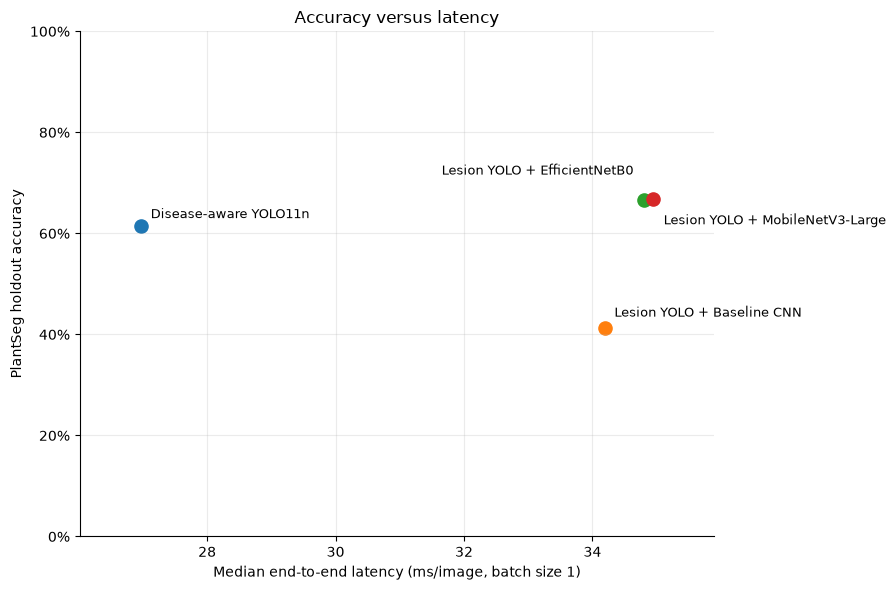

**Benchmark platform:** arm64 / macOS-26.6.2-arm64-arm-64bit-Mach-O; device: `mps`; 200 timed images after 10 warm-up images.

In [6]:
efficiency_path = artifacts['Efficiency']
if efficiency_path.is_file() and primary_path.is_file():
    efficiency = json.loads(efficiency_path.read_text())
    accuracy_by_system = {
        'standalone_yolo': primary['standalone_yolo']['classification']['accuracy'],
        **{name: values['accuracy'] for name, values in primary['classification'].items()},
    }
    display_names = {
        'standalone_yolo': 'Disease-aware YOLO11n',
        'baseline_cnn': 'Lesion YOLO + Baseline CNN',
        'efficientnet_b0': 'Lesion YOLO + EfficientNetB0',
        'mobilenet_v3_large': 'Lesion YOLO + MobileNetV3-Large',
    }
    efficiency_rows = []
    for system, measurements in efficiency['systems'].items():
        efficiency_rows.append({
            'System': display_names[system],
            'Holdout accuracy': accuracy_by_system[system],
            'Median latency (ms)': measurements['latency_median_ms'],
            'P95 latency (ms)': measurements['latency_p95_ms'],
            'Throughput (images/s)': measurements['throughput_images_per_second'],
            'Parameters (M)': measurements['parameters'] / 1e6,
        })
    efficiency_df = pd.DataFrame(efficiency_rows)
    display(efficiency_df.style.format({
        'Holdout accuracy': '{:.1%}', 'Median latency (ms)': '{:.1f}',
        'P95 latency (ms)': '{:.1f}', 'Throughput (images/s)': '{:.1f}',
        'Parameters (M)': '{:.2f}',
    }).hide(axis='index'))

    fig, axis = plt.subplots(figsize=(9, 6))
    colors = plt.get_cmap('tab10').colors
    annotation_style = {
        'Disease-aware YOLO11n': ((7, 6), 'left'),
        'Lesion YOLO + Baseline CNN': ((7, 8), 'left'),
        'Lesion YOLO + EfficientNetB0': ((-8, 18), 'right'),
        'Lesion YOLO + MobileNetV3-Large': ((8, -18), 'left'),
    }
    for color, row in zip(colors, efficiency_rows, strict=False):
        axis.scatter(row['Median latency (ms)'], row['Holdout accuracy'], s=90, color=color)
        offset, alignment = annotation_style[row['System']]
        axis.annotate(row['System'],
                      (row['Median latency (ms)'], row['Holdout accuracy']),
                      xytext=offset, textcoords='offset points', fontsize=9,
                      horizontalalignment=alignment)
    axis.set(xlabel='Median end-to-end latency (ms/image, batch size 1)',
             ylabel='PlantSeg holdout accuracy', ylim=(0, 1),
             title='Accuracy versus latency')
    axis.yaxis.set_major_formatter(PercentFormatter(1))
    axis.margins(x=.12)
    axis.grid(alpha=.25)
    fig.tight_layout()
    plt.show()
    display(Markdown(
        f"**Benchmark platform:** {efficiency['hardware']}; device: `{efficiency['device']}`; "
        f"{efficiency['sample_size']} timed images after {efficiency['warmup_images']} warm-up images."
    ))
else:
    display(Markdown('> Efficiency results are unavailable. Run the efficiency benchmark script.'))

## 8. PlantVillage cross-domain evaluation

**Purpose.** Measure transfer from field photographs to controlled imagery using the same 21
mapped diseases in both datasets. Both subsets pass through unchanged detector, crop policy,
classifier, and preprocessing settings; no PlantVillage fine-tuning is performed.

The change is **PlantVillage minus matched PlantSeg**, so a negative value indicates degradation.
This is a separate comparison from the full 115-class holdout. Expected calibration error (ECE)
measures the gap between confidence and empirical correctness; lower is better.

The single-stage comparison uses the disease-aware YOLO11n checkpoint on the same images.
Its highest-confidence box supplies the disease prediction; a missed detection counts as an
incorrect prediction with confidence zero. Predictions outside the 21 shared labels remain
errors for every system. Coverage reports how often a system returns a class. YOLO ECE includes
all images, assigning confidence zero to missed detections; its scores are detection confidences,
whereas the cascades use classifier softmax confidence. No PlantVillage box annotations are
required for this image-level comparison, so cross-domain detection mAP is not reported.


System,PlantSeg accuracy,PlantVillage accuracy,Accuracy change,PlantSeg macro F1,PlantVillage macro F1,Macro F1 change,PlantVillage ECE,PlantSeg coverage,PlantVillage coverage
baseline_cnn,0.302,0.075,-0.226,0.345,0.109,-0.236,0.148,1.000,1.000
efficientnet_b0,0.582,0.323,-0.259,0.636,0.357,-0.279,0.428,1.000,1.000
mobilenet_v3_large,0.601,0.371,-0.229,0.647,0.390,-0.257,0.382,1.000,1.000
Disease-aware YOLO11n,0.561,0.112,-0.449,0.639,0.176,-0.463,0.120,0.868,0.432


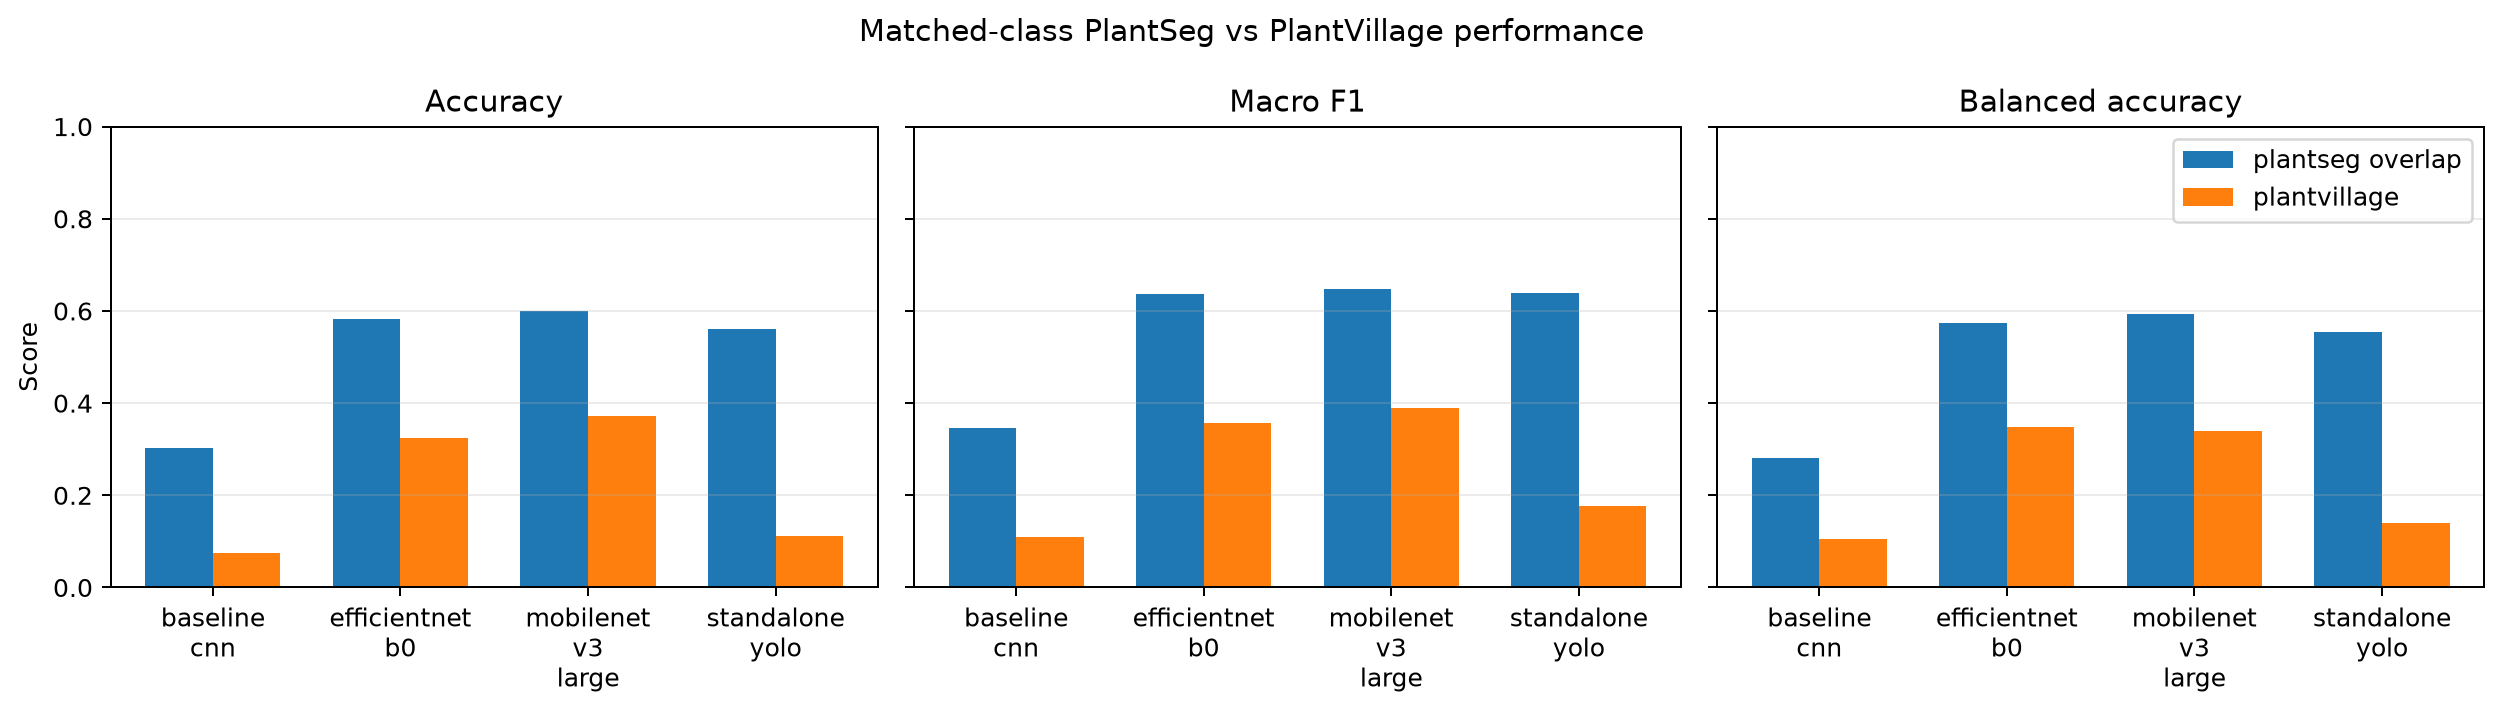

In [7]:
cross_path = artifacts['Cross-domain']
if cross_path.is_file():
    cross = json.loads(cross_path.read_text())
    cross_rows = []
    for model in cross['domains']['plantseg_overlap']['classification']:
        source = cross['domains']['plantseg_overlap']['classification'][model]
        target = cross['domains']['plantvillage']['classification'][model]
        cross_rows.append({
            'System': 'Disease-aware YOLO11n' if model == 'standalone_yolo' else model, 'PlantSeg accuracy': source['accuracy'], 'PlantVillage accuracy': target['accuracy'],
            'Accuracy change': target['accuracy'] - source['accuracy'],
            'PlantSeg macro F1': source['macro_f1'], 'PlantVillage macro F1': target['macro_f1'],
            'Macro F1 change': target['macro_f1'] - source['macro_f1'],
            'PlantVillage ECE': target['expected_calibration_error'],
            'PlantSeg coverage': source.get('coverage', 1.0),
            'PlantVillage coverage': target.get('coverage', 1.0),
        })
    display(pd.DataFrame(cross_rows).style.format(precision=3).hide(axis='index'))
    image_path = cross_path.parent / 'domain_comparison.png'
    if image_path.is_file():
        from IPython.display import Image as DisplayImage
        display(DisplayImage(filename=str(image_path)))
else:
    display(Markdown('> Cross-domain results are not available. Run the cross-domain command in section 12.'))


## 9. Robustness under synthetic corruption

**Purpose.** Test how the full detector-classifier pipeline responds to degraded image quality.
Six corruptions are applied to the same fixed 200-image subset at severity levels 1-5, and the
lesion detector is rerun for every transformed image. Performance changes can therefore arise
from either localization or classification.

Each panel plots accuracy against severity for all three classifiers. Severity 0 is the clean
baseline on the same subset. Steeper declines indicate greater sensitivity. Severity is an ordinal
setting within each corruption and should not be compared as an equivalent physical magnitude
between different corruption types.


**Robustness run:** `outputs/imported_checkpoints/d642c4c7a00b6832/evaluations/robustness`; **images:** 200.

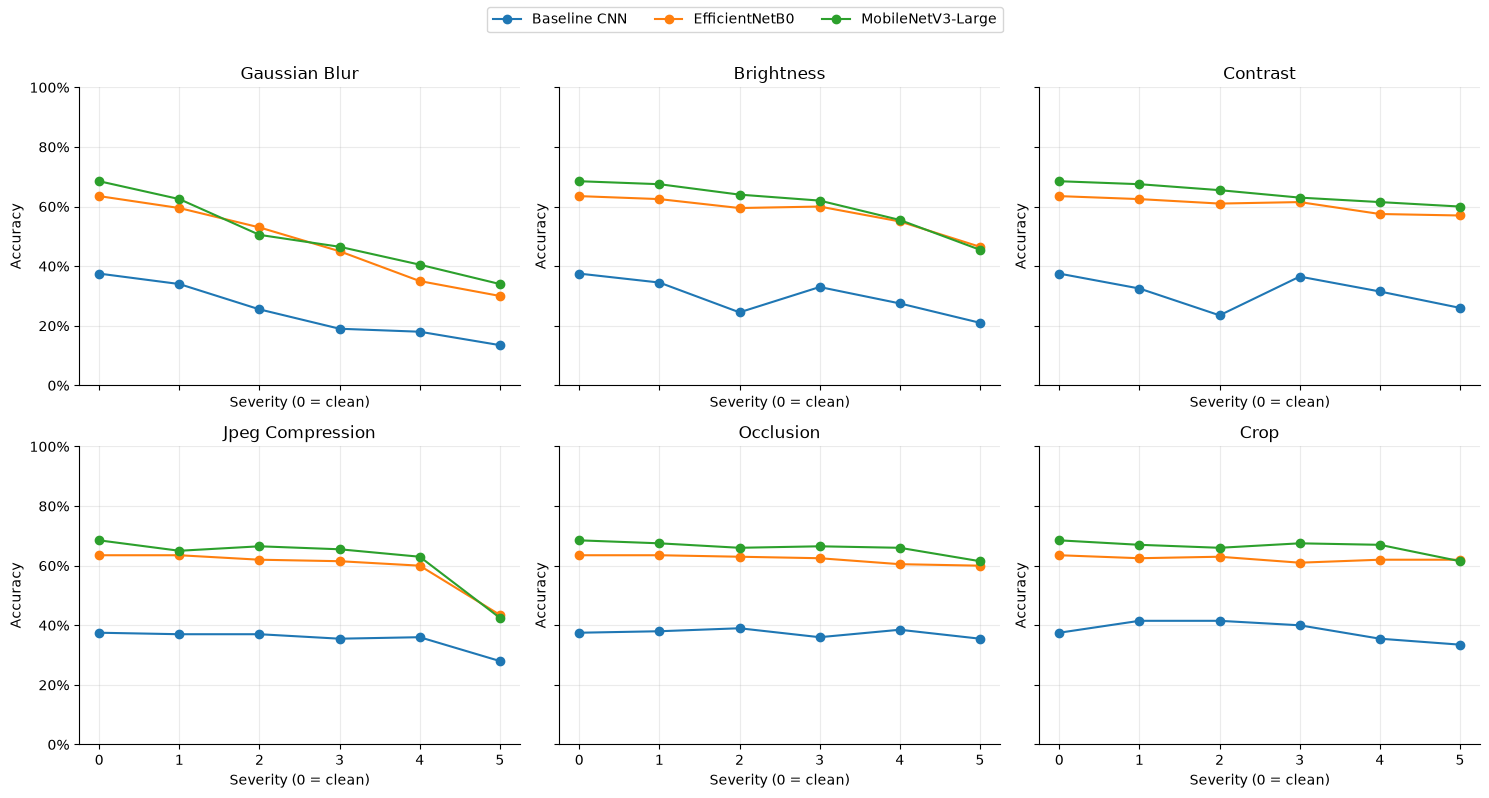

In [8]:
robust_path = artifacts['Robustness (full)'] if artifacts['Robustness (full)'].is_file() else artifacts['Robustness (subset)']
if robust_path.is_file():
    robust = json.loads(robust_path.read_text())
    robust_df = pd.DataFrame(robust.get('records', []))
    display(Markdown(f"**Robustness run:** `{robust_path.parent.relative_to(ROOT)}`; "
                     f"**images:** {robust.get('subset_size', 'not recorded')}."))
    if not robust_df.empty and {'model', 'corruption', 'severity', 'accuracy'} <= set(robust_df.columns):
        corruptions = [name for name in robust_df['corruption'].unique() if name != 'clean']
        models = list(robust_df['model'].unique())
        colors = dict(zip(models, plt.get_cmap('tab10').colors))
        if corruptions:
            fig, axes = plt.subplots(int(np.ceil(len(corruptions) / 3)), 3,
                                     figsize=(15, 4 * int(np.ceil(len(corruptions) / 3))),
                                     sharex=True, sharey=True, squeeze=False)
            for axis, corruption in zip(axes.flat, corruptions):
                for model in models:
                    points = robust_df[(robust_df['model'] == model) &
                                       (robust_df['corruption'] == corruption)][['severity', 'accuracy']]
                    clean = robust_df[(robust_df['model'] == model) & (robust_df['corruption'] == 'clean')]
                    baseline = clean['accuracy'].iloc[0] if not clean.empty else robust.get('clean_baseline', {}).get(model, {}).get('accuracy')
                    if not points.empty:
                        if baseline is not None:
                            points = pd.concat([pd.DataFrame([{'severity': 0, 'accuracy': baseline}]), points])
                        points = points.sort_values('severity')
                        axis.plot(points['severity'], points['accuracy'], marker='o',
                                  color=colors[model], label=model_labels.get(model, model))
                axis.set(title=corruption.replace('_', ' ').title(), xlabel='Severity (0 = clean)',
                         ylabel='Accuracy', ylim=(0, 1), xticks=range(6))
                axis.yaxis.set_major_formatter(PercentFormatter(1))
                axis.grid(alpha=.25)
            for axis in list(axes.flat)[len(corruptions):]: axis.set_visible(False)
            handles, labels = axes.flat[0].get_legend_handles_labels()
            fig.legend(handles, labels, loc='upper center', ncol=len(models))
            fig.tight_layout(rect=(0, 0, 1, .94))
            plt.show()
        else:
            display(Markdown('> Only the clean baseline is available; corruption measurements are pending.'))
    elif (robust_path.parent / 'accuracy_vs_severity.png').is_file():
        fig, axis = plt.subplots(figsize=(15, 8))
        axis.imshow(plt.imread(robust_path.parent / 'accuracy_vs_severity.png'))
        axis.axis('off'); plt.show()
    else:
        display(Markdown('> No plottable robustness records are available in this summary.'))
else:
    display(Markdown('> Robustness results are unavailable. Generate them with the selected weights using the command below.'))


## 10. Grad-CAM against lesion masks

**Purpose.** Examine whether classifier attention aligns with annotated disease regions. Grad-CAM
maps are compared with PlantSeg masks in image coordinates. Top-20% IoU measures overlap of the
most activated region, mask-energy fraction measures how much attention lies inside the lesion,
and the pointing-game score measures whether the strongest activation falls within the mask.

Higher values indicate stronger spatial alignment, but Grad-CAM is an explanation signal rather
than a verified segmentation method or proof of causal reasoning. The qualitative examples help
show patterns that aggregate scores can hide.


**Model:** mobilenet_v3_large; **images:** 1561.

,Mean,Median
iou_fixed,0.213,0.189
precision_fixed,0.516,0.500
recall_fixed,0.313,0.284
iou_top_quantile,0.242,0.221
precision_top_quantile,0.412,0.342
recall_top_quantile,0.527,0.481
mask_energy_fraction,0.415,0.382
mask_area_fraction,0.213,0.142
pointing_game_hit,0.588,1.000


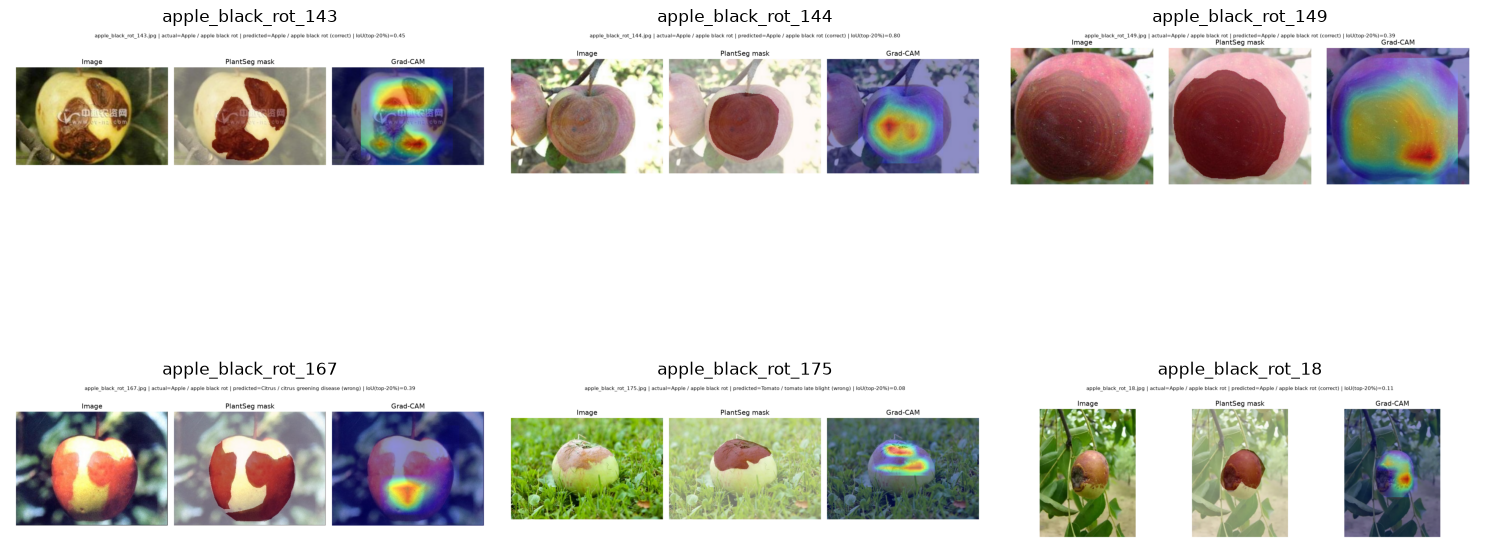

In [9]:
gradcam_path = artifacts['Grad-CAM']
if gradcam_path.is_file():
    gradcam = json.loads(gradcam_path.read_text())
    display(Markdown(f"**Model:** {gradcam.get('model', 'not recorded')}; **images:** {gradcam.get('images', 'not recorded')}."))
    metrics = pd.DataFrame({'Mean': gradcam.get('metrics_mean', {}), 'Median': gradcam.get('metrics_median', {})})
    display(metrics.style.format(precision=3))
    figures = sorted((gradcam_path.parent / 'figures').glob('*.png'))[:6]
    if figures:
        fig, axes = plt.subplots(2, 3, figsize=(15, 9))
        for axis in axes.flat: axis.axis('off')
        for axis, path in zip(axes.flat, figures):
            axis.imshow(plt.imread(path)); axis.set_title(path.stem); axis.axis('off')
        plt.tight_layout(); plt.show()
else:
    display(Markdown('> Grad-CAM artifacts are not present in this checkout. Run the Grad-CAM command in section 12.'))


## 11. Qualitative detection and classification examples

**Purpose.** Inspect individual successes and failures that aggregate scores cannot show. Six
reproducibly sampled PlantSeg test photographs are processed by the lesion detector and
MobileNetV3-Large classifier. Titles show the reference disease, predicted disease, and confidence;
green and red boxes distinguish correct and incorrect predictions.

The examples use the same expanded lesion crop and full-image fallback policy as the quantitative
evaluation. Confidence is a model score rather than a guarantee of correctness, and this small
sample is intended for inspection rather than performance estimation.


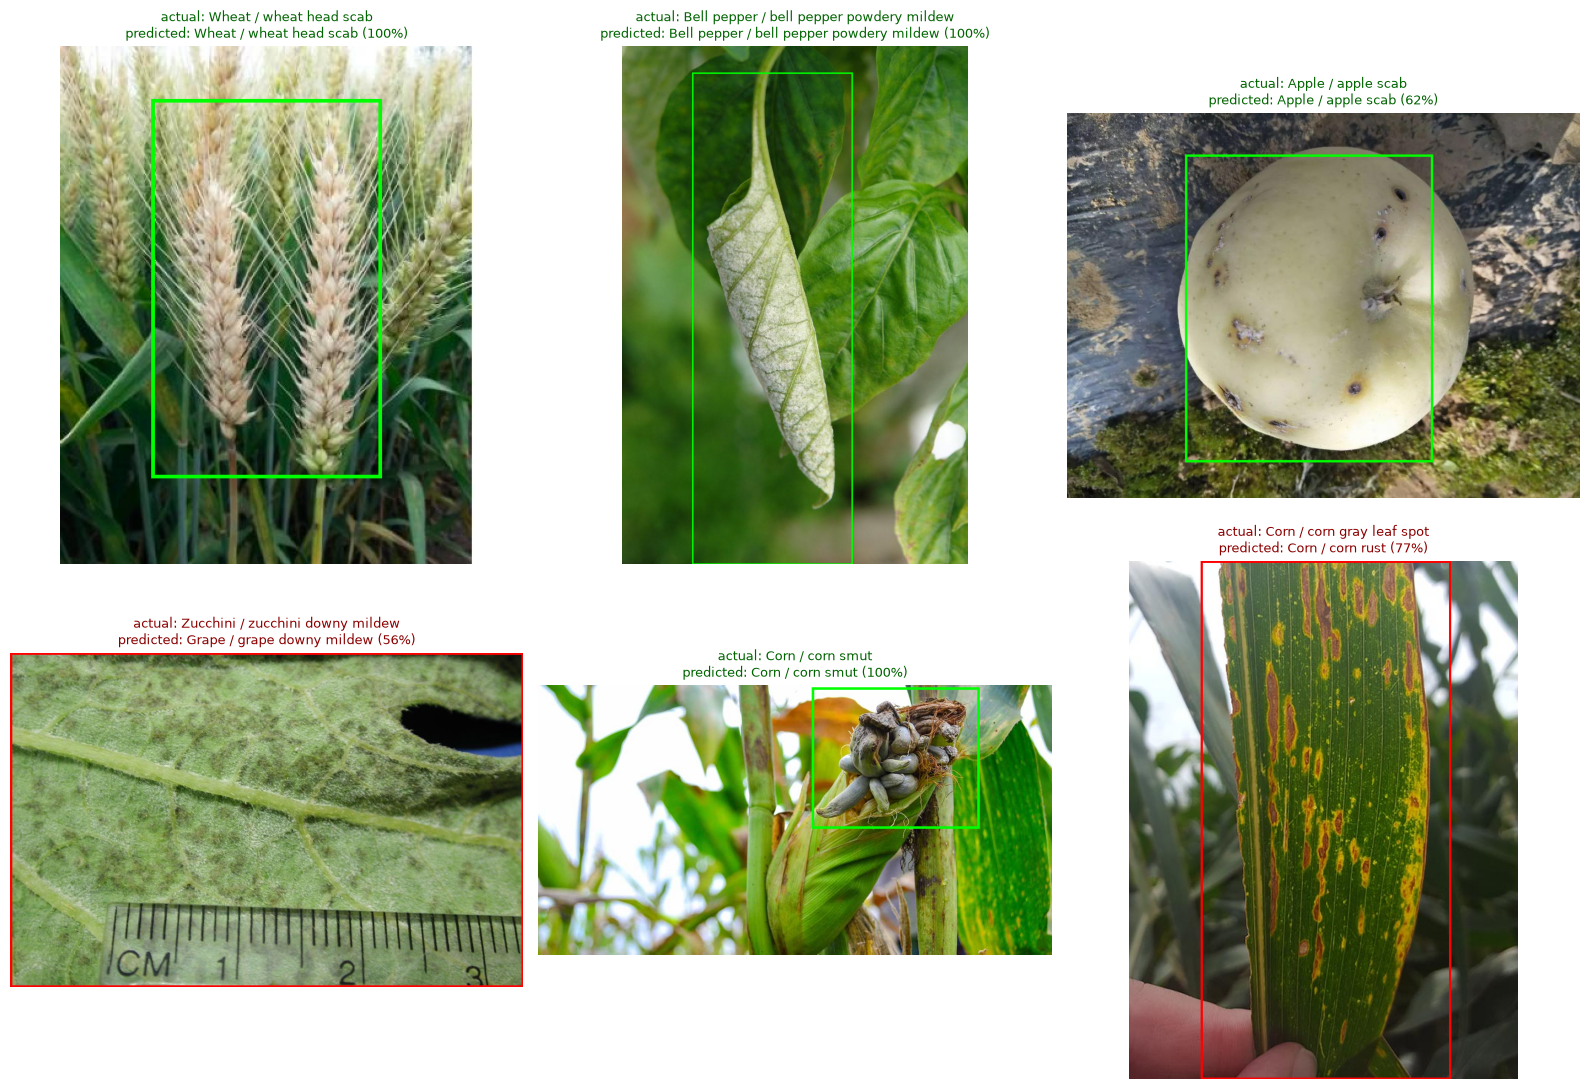

In [10]:
import csv
import random

import torch
from PIL import Image, ImageDraw
from ultralytics import YOLO

import sys
sys.path.insert(0, str(ROOT / 'src'))
from plant_disease.models import build_classifier, classification_transform
sys.path.insert(0, str(ROOT / 'scripts'))
from evaluate_pipeline import expanded_union_box

import yaml
config = yaml.safe_load((ROOT / 'configs' / 'project.yaml').read_text())
detection = config['detection']
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')

lesion_checkpoint = CHECKPOINTS / 'yolo' / detection['run_name'] / 'weights' / 'best.pt'
classifier_checkpoint = CHECKPOINTS / 'classification' / 'mobilenet_v3_large' / 'best.pt'
test_root = ROOT / 'data' / 'tests' / 'PlantSeg' / 'full'

if lesion_checkpoint.is_file() and classifier_checkpoint.is_file() and (test_root / 'Metadata.csv').is_file():
    detector = YOLO(lesion_checkpoint)
    checkpoint = torch.load(classifier_checkpoint, map_location='cpu', weights_only=True)
    class_names = checkpoint['class_names']
    classifier = build_classifier('mobilenet_v3_large', len(class_names), pretrained=False)
    classifier.load_state_dict(checkpoint['model_state_dict'])
    classifier.eval().to(device)
    transform = classification_transform(config['project']['image_size'])

    with (test_root / 'Metadata.csv').open(encoding='utf-8-sig', newline='') as handle:
        rows = list(csv.DictReader(handle))
    sample_rows = random.Random(config['project']['seed']).sample(rows, min(6, len(rows)))

    fig, axes = plt.subplots(2, 3, figsize=(16, 11))
    for axis in axes.flat: axis.axis('off')
    for axis, row in zip(axes.flat, sample_rows):
        image_path = test_root / 'images' / row['Name']
        image = Image.open(image_path).convert('RGB')
        width, height = image.size
        results = detector.predict(source=str(image_path), conf=detection['crop_confidence'], imgsz=detection['image_size'], device=device, verbose=False)
        boxes = results[0].boxes.xyxy.detach().cpu().numpy()

        annotated = image.copy()
        draw = ImageDraw.Draw(annotated)
        actual_class = f"{row['Plant']} / {row['Disease']}"

        if len(boxes):
            bounds = expanded_union_box(boxes, width, height, detection['crop_margin'])
            crop = image.crop(bounds)
        else:
            bounds = (0, 0, width, height)
            crop = image
        tensor = transform(crop).unsqueeze(0).to(device)
        with torch.inference_mode():
            probabilities = classifier(tensor).softmax(dim=1)
        confidence, predicted_id = probabilities.max(dim=1)
        predicted_class = class_names[predicted_id.item()]
        correct = predicted_id.item() == int(row['Index'])
        draw.rectangle(bounds, outline='lime' if correct else 'red', width=max(3, width // 200))
        label = f"{predicted_class} ({confidence.item():.0%})"
        if not len(boxes): label += ' [full-image fallback]'

        axis.imshow(annotated)
        axis.set_title(f"actual: {actual_class}\npredicted: {label}", fontsize=9, color='darkgreen' if correct else 'darkred')
        axis.axis('off')
    plt.tight_layout()
    plt.show()
else:
    missing = [str(p) for p in (lesion_checkpoint, classifier_checkpoint, test_root) if not p.exists()]
    display(Markdown(f'> Required checkpoint or data not found: {missing}. Run `make train-pipeline` first.'))
